# Social Media Engagement Analytics.

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Task 1 — Data Import & Setup

#### Import CSV using Pandas

In [7]:
df = pd.read_csv("social_media_engagement_5000.csv")

#### Check/convert data types

In [3]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [4]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [5]:
df.shape

(5000, 19)

In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [8]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [9]:
df['posted_at'].head()

0    17-12-2022
1    02-06-2023
2    07-05-2023
3    12-02-2023
4    23-05-2023
Name: posted_at, dtype: object

In [10]:
# Convert date columns to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], dayfirst=True)

In [11]:
df['posted_at'].dtype

dtype('<M8[ns]')

In [12]:
df['posted_at'].head()

0   2022-12-17
1   2023-06-02
2   2023-05-07
3   2023-02-12
4   2023-05-23
Name: posted_at, dtype: datetime64[ns]

*********************************

#### NumPy Array Operation:
Converted the likes column into a NumPy array and calculated the mean while ignoring missing values using np.nanmean().

In [13]:
likes_array = df['likes'].values

In [14]:
likes_array

array([ 7011., 11750.,  4862., ..., 13487., 16894., 14830.], shape=(5000,))

In [15]:
np.nanmean(likes_array)

np.float64(10107.043711340206)

********************************

### Task 2 — Data Cleaning

In [16]:
# Detect missing values
df.isna().sum()

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64

*********************************

In [17]:
df['gender'].unique()

array(['Female', 'Male', 'Other', nan], dtype=object)

In [18]:
df['gender'].value_counts()

gender
Male      1699
Other     1581
Female    1570
Name: count, dtype: int64

In [19]:
# Using mode value to fill the missing values in Gender column
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [20]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [21]:
df['gender'].value_counts()

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

In [22]:
df['gender'].isna().sum()

np.int64(0)

**********************************

##### Checking for outliers in age column, using IQR method

In [23]:
Q1 = df.age.quantile(0.25)
Q3= df.age.quantile(0.75)
Q1,Q3

(np.float64(26.0), np.float64(51.0))

In [24]:
IQR = Q3-Q1
IQR

np.float64(25.0)

In [25]:
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
lower_limit,upper_limit

(np.float64(-11.5), np.float64(88.5))

In [26]:
df[(df.age<lower_limit)|(df.age>upper_limit)]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate


In [27]:
df['age'].mean()

np.float64(38.454020618556704)

In [28]:
df['age'].median()

38.0

In [29]:
# No outliers were detected using the IQR method, and the mean (38.45) is close to the median (38), so mean imputation is used for age.
df['age'] = df['age'].fillna(df['age'].mean())

In [30]:
df['age'].isna().sum()

np.int64(0)

*************************************

In [31]:
df['likes'].mean()

np.float64(10107.043711340206)

In [32]:
df['likes'].median()

10105.5

In [33]:
Q1 = df['likes'].quantile(0.25)
Q3 = df['likes'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [34]:
df[(df['likes'] < lower_limit) | (df['likes'] > upper_limit)]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate


In [35]:
# No outliers were detected using the IQR method, and the mean (10,107.04) is close to the median (10,105.5), so mean imputation is used for likes.
df['likes'] = df['likes'].fillna(df['likes'].mean())

In [36]:
df['likes'].isna().sum()

np.int64(0)

***********************************************

In [37]:
df['comments'].mean()

np.float64(1502.1956701030929)

In [38]:
df['comments'].median()

1497.0

In [39]:
Q1 = df['comments'].quantile(0.25)
Q3 = df['comments'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [40]:
df[(df['comments'] < lower_limit) | (df['comments'] > upper_limit)]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate


In [41]:
# No outliers were detected using the IQR method, and the mean (1,502.20) is close to the median (1,497), so mean imputation is used for comments.
df['comments'] = df['comments'].fillna(df['comments'].mean())

In [42]:
df['comments'].isna().sum()

np.int64(0)

**************************************

In [43]:
df['shares'].mean()

np.float64(1002.6294845360825)

In [44]:
df['shares'].median()

1012.0

In [45]:
Q1 = df['shares'].quantile(0.25)
Q3 = df['shares'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [46]:
df[(df['shares'] < lower_limit) | (df['shares'] > upper_limit)]

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate


In [47]:
# No outliers were detected using the IQR method, and the mean (1,002.63) is close to the median (1,012), so mean imputation is used for shares.
df['shares'] = df['shares'].fillna(df['shares'].mean())

In [48]:
df['shares'].isna().sum()

np.int64(0)

***************************************************

In [49]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral', nan], dtype=object)

In [50]:
df['sentiment'].value_counts()

sentiment
positive    2363
neutral     1527
negative     960
Name: count, dtype: int64

In [51]:
# As sentiment is categorical and positive is the most frequent category, mode imputation was used to fill the missing values.
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [52]:
df['sentiment'].isna().sum()

np.int64(0)

In [53]:
df.isna().sum()

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64

***********************************************

In [54]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

##### Data Formatting

In [55]:
df['post_type'].unique()

array(['image', 'reel', 'text', 'video'], dtype=object)

In [56]:
df['post_category'].unique()

array(['fitness', 'food', 'tech', 'travel', 'fashion', 'lifestyle',
       'education', 'music'], dtype=object)

In [57]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [58]:
df['is_verified'].unique()

array([False,  True])

In [59]:
df['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [60]:
df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

##### Feature Cleaning

In [61]:
df['hashtags'].head()

0    #foodie #travel #love
1                 #fitness
2                  #foodie
3      #music #foodie #fun
4                  #travel
Name: hashtags, dtype: object

In [62]:
hashtag_count = []
for i in df['hashtags']:
    hashtag_count.append(len(i.split()))

In [63]:
df['hashtag_count'] = hashtag_count

In [64]:
df[['hashtags', 'hashtag_count']].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


##### Correcting unrealistic values in likes/comments/shares.

In [65]:
df[['likes', 'comments', 'shares']].describe()

,likes,comments,shares
count,5000.000000,5000.000000,5000.000000
mean,10107.043711,1502.195670,1002.629485
std,5702.293011,856.392853,570.852962
min,10.000000,0.000000,0.000000
25%,5235.000000,792.000000,511.000000
50%,10107.043711,1502.195670,1002.629485
75%,14959.000000,2235.250000,1483.000000
max,19998.000000,2999.000000,1999.000000


In [66]:
df[['likes', 'comments', 'shares']].lt(0).sum()

likes       0
comments    0
shares      0
dtype: int64

In [67]:
# No unrealistic or negative values were found in likes, comments, or shares, so no corrections were required.

In [68]:
# Converted likes, comments, and shares to integers since they represent whole-number counts.
df[['likes', 'comments', 'shares']] = df[['likes', 'comments', 'shares']].round().astype(int)

In [69]:
# Converted 'age' to integers since they represent whole-number.
df['age'] = df['age'].round().astype(int)

### Task 3 — Data Exploration using Pandas

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [71]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [72]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [73]:
df.shape

(5000, 20)

In [74]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [75]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10107.042400,1502.189800,1002.640600,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10107.000000,1502.000000,1003.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293011,856.392854,570.852965,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


*****************************************

In [76]:
df['post_type'].value_counts()

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

In [77]:
df['post_category'].value_counts()

post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64

In [78]:
df['country'].value_counts()

country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

In [79]:
df['gender'].value_counts()

gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

In [80]:
df['device_type'].value_counts()

device_type
mobile     1684
tablet     1658
desktop    1658
Name: count, dtype: int64

In [81]:
df['is_verified'].value_counts()

is_verified
False    4517
True      483
Name: count, dtype: int64

In [82]:
df['sentiment'].value_counts()

sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64

##### Numeric relationships

In [83]:
# Identify numeric columns
df.select_dtypes(include=np.number).columns

Index(['user_id', 'age', 'post_id', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate', 'hashtag_count'],
      dtype='object')

In [84]:
corr = df[['age', 'likes', 'comments', 'shares',
    'watch_time_sec', 'impression_count',
    'follower_count', 'engagement_rate', 'hashtag_count']].corr()
corr

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.000000,-0.036322,-0.007284,0.013865,0.005542,0.013322,-0.024894,0.008039,0.007173
likes,-0.036322,1.000000,-0.018424,0.004654,0.008711,0.007953,-0.022981,0.093520,-0.002189
comments,-0.007284,-0.018424,1.000000,0.006131,-0.016347,-0.009392,-0.011742,0.000046,-0.015231
shares,0.013865,0.004654,0.006131,1.000000,0.014671,-0.005098,-0.010743,0.021729,0.013448
watch_time_sec,0.005542,0.008711,-0.016347,0.014671,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.013322,0.007953,-0.009392,-0.005098,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,-0.024894,-0.022981,-0.011742,-0.010743,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,0.008039,0.093520,0.000046,0.021729,-0.001148,-0.232226,0.002292,1.000000,0.005319
hashtag_count,0.007173,-0.002189,-0.015231,0.013448,-0.023301,-0.002714,0.008802,0.005319,1.000000


###### 📝A correlation matrix was created for the meaningful numeric fields, excluding user_id and post_id because they are identifiers rather than analytical measures. Most variables show very weak linear correlations, with the strongest observed relationship being a weak negative correlation between impression_count and engagement_rate (-0.232).

***************************************

##### Grouped summaries using groupby()

In [85]:
# Avg likes by post type
df.groupby('post_type')['likes'].mean()

post_type
image    10104.903769
reel     10037.855027
text     10100.195181
video    10188.641633
Name: likes, dtype: float64

In [86]:
# Impressions by country
df.groupby('country')['impression_count'].sum()

country
Australia    23834767
Brazil       24793360
Canada       24984716
France       25656926
Germany      23816649
India        28067377
Japan        23418816
UAE          24610992
UK           25201861
USA          25683200
Name: impression_count, dtype: int64

In [87]:
# Average engagement rate by device type
df.groupby('device_type')['engagement_rate'].mean()

device_type
desktop    0.962006
mobile     1.123999
tablet     0.804560
Name: engagement_rate, dtype: float64

In [88]:
# Average watch time by post type
df.groupby('post_type')['watch_time_sec'].mean()

post_type
image    3881.448276
reel     4135.727202
text     4010.873092
video    4026.673469
Name: watch_time_sec, dtype: float64

****************************************

### Task 4 — Data Wrangling

In [89]:
# No merge, concat, or join required because the analysis uses a single DataFrame.

In [90]:
# hashtag_count field: Already created in Task 2

In [91]:
# Create an engagement_score field.
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

In [92]:
df['engagement_score'].head()

0     8522
1    16163
2     6161
3     7482
4    16717
Name: engagement_score, dtype: int64

In [93]:
# Create a new log-transformed metrics field. 
df['log_engagement_rate'] = np.log(df['engagement_rate'])

In [94]:
df['log_engagement_rate'].describe()

count    5000.000000
mean       -1.221413
std         1.147130
min        -5.057270
25%        -1.925649
50%        -1.370831
75%        -0.683605
max         5.254911
Name: log_engagement_rate, dtype: float64

###### 📝Log transformation was applied to engagement rate to reduce the impact of extreme values caused by its highly right-skewed distribution.

*******************************************************

##### Perform groupby summaries by post_type, country, and sentiment.

In [95]:
# Which type gets the most interactions?
df.groupby('post_type')['engagement_score'].mean()

post_type
image    12649.321572
reel     12523.974279
text     12613.164659
video    12664.498776
Name: engagement_score, dtype: float64

In [96]:
# Which country's posts have the highest engagement relative to impressions?
df.groupby('country')['engagement_rate'].mean()

country
Australia    1.324339
Brazil       1.540704
Canada       0.916659
France       1.146402
Germany      0.759000
India        0.655005
Japan        0.769623
UAE          1.112352
UK           0.850966
USA          0.576580
Name: engagement_rate, dtype: float64

In [97]:
# Which sentiment receives the most interactions?
df.groupby('sentiment')['engagement_score'].mean()

sentiment
negative    12731.445833
neutral     12448.105435
positive    12665.705929
Name: engagement_score, dtype: float64

###### 📝Groupby analysis shows that video posts have the highest average engagement score, Brazil has the highest average engagement rate, and negative-sentiment posts have the highest average engagement score.

****************************************************

### Task 5 — Statistical Analysis

In [98]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score', 'log_engagement_rate'],
      dtype='object')

##### Compute descriptive stats for likes, comments, shares, watch_time, engagement_rate, followers

In [99]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].mean()

likes               10107.042400
comments             1502.189800
shares               1002.640600
watch_time_sec       4014.503200
engagement_rate         0.964356
follower_count     393698.224800
dtype: float64

In [100]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].median()

likes               10107.000000
comments             1502.000000
shares               1003.000000
watch_time_sec       4034.500000
engagement_rate         0.253896
follower_count     388982.000000
dtype: float64

In [101]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'follower_count']].mode().iloc[0]

likes              10107.0
comments            1502.0
shares              1003.0
watch_time_sec       916.0
follower_count    497502.0
Name: 0, dtype: float64

###### 📝Engagement rate has no meaningful mode because its values are predominantly unique.

In [102]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].std()

likes                5702.293011
comments              856.392854
shares                570.852965
watch_time_sec       2308.096459
engagement_rate         5.318029
follower_count     230927.884535
dtype: float64

In [103]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].var()

likes              3.251615e+07
comments           7.334087e+05
shares             3.258731e+05
watch_time_sec     5.327309e+06
engagement_rate    2.828143e+01
follower_count     5.332769e+10
dtype: float64

In [104]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].quantile([0.25, 0.50, 0.75])

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10107.0,1502.00,1003.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [105]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].skew()

likes              -0.006917
comments            0.003276
shares             -0.013234
watch_time_sec     -0.018196
engagement_rate    18.781271
follower_count      0.041118
dtype: float64

In [106]:
df[['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']].kurt()

likes               -1.149992
comments            -1.144373
shares              -1.146854
watch_time_sec      -1.195652
engagement_rate    482.991739
follower_count      -1.189474
dtype: float64

###### 📝Engagement rate showed extreme positive skewness (18.78) and high kurtosis (482.99), indicating a strong right tail and presence of extreme values. A log transformation was therefore applied to reduce the influence of these extreme values.

****************************************

### Task 6 — Data Visualization 

#### 📍Scatter Plot

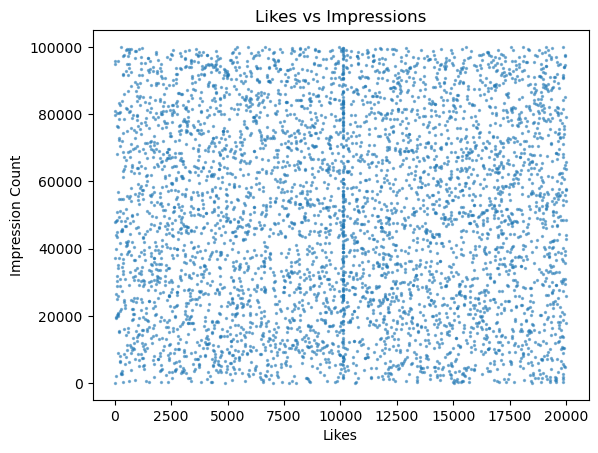

In [107]:
plt.scatter(df['likes'], df['impression_count'], s=2, alpha=0.5)
plt.xlabel('Likes')
plt.ylabel('Impression Count')
plt.title('Likes vs Impressions')
plt.show()

###### 📝Likes and impression count show little to no linear relationship, as the scatter plot shows a widely dispersed pattern.

*************************************************

#### 📈 Line Plot

In [108]:
# New date column created from 'posted_at'. 
df['posted_date']= df['posted_at'].dt.date

In [109]:
df['posted_date'].head()

0    2022-12-17
1    2023-06-02
2    2023-05-07
3    2023-02-12
4    2023-05-23
Name: posted_date, dtype: object

In [110]:
daily_engagement_trend = df.groupby('posted_date')['engagement_score'].mean()
daily_engagement_trend

posted_date
2022-01-01    12018.333333
2022-01-02    12058.125000
2022-01-03    11628.800000
2022-01-04    10576.666667
2022-01-05    12982.700000
                  ...     
2023-12-27     7411.000000
2023-12-28    14665.000000
2023-12-29    13553.000000
2023-12-30     9618.500000
2023-12-31    11088.000000
Name: engagement_score, Length: 729, dtype: float64

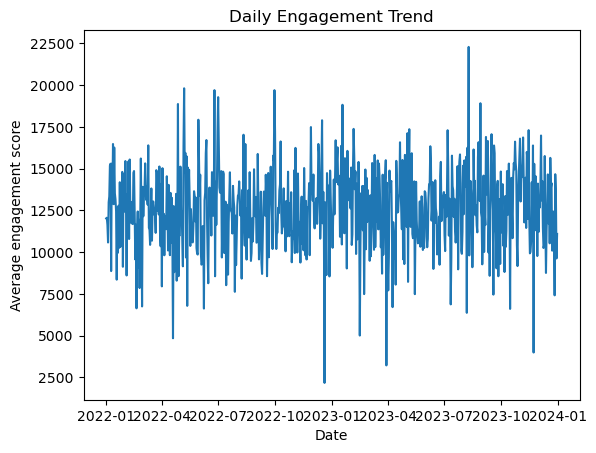

In [111]:
plt.plot(daily_engagement_trend.index, daily_engagement_trend.values)
plt.xlabel('Date')
plt.ylabel('Average engagement score')
plt.title('Daily Engagement Trend')
plt.show()

###### 📝Daily average engagement fluctuates considerably over time, with several spikes and dips, but no clear long-term trend is visible.

**********************************************

#### 📊 Bar Plot

In [112]:
posts_by_category = df.groupby('post_category')['post_category'].count()
posts_by_category

post_category
education    631
fashion      594
fitness      675
food         593
lifestyle    607
music        635
tech         665
travel       600
Name: post_category, dtype: int64

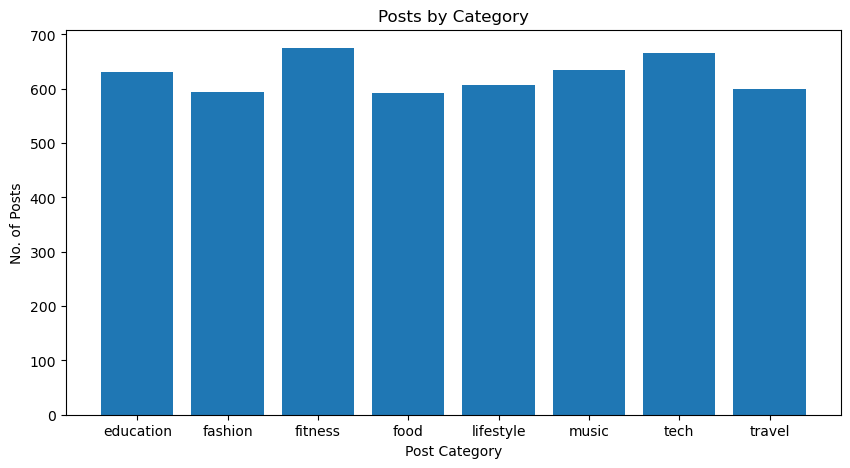

In [113]:
plt.figure(figsize=(10,5))
plt.bar(posts_by_category.index, posts_by_category.values)
plt.xlabel('Post Category')
plt.ylabel('No. of Posts')
plt.title('Posts by Category')
plt.show()

###### 📝Fitness has the highest number of posts, while food has the lowest. Overall, post distribution is fairly balanced across categories.

*************************************************

#### 🥧 Pie Plot

In [114]:
gender_destribution = df.groupby('gender')['gender'].count()
gender_destribution

gender
Female    1570
Male      1849
Other     1581
Name: gender, dtype: int64

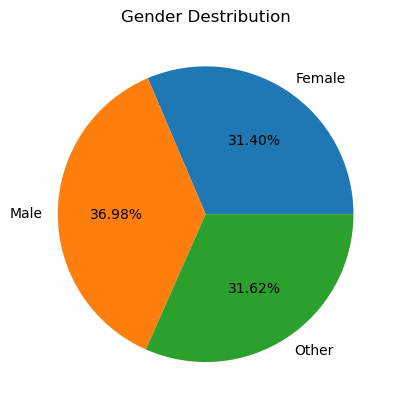

In [115]:
plt.pie(gender_destribution, labels = gender_destribution.index, autopct="%1.2f%%")
plt.title('Gender Destribution')
plt.show()

###### 📝Male users represent the largest gender group at 36.98%, while Female and Other users have similar proportions.

**************************************

#### 📊 Histogram

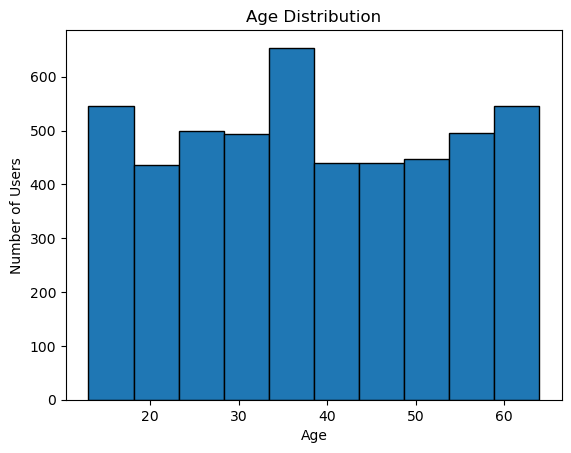

In [116]:
plt.hist(df['age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.title('Age Distribution')
plt.show()

###### 📝Users are distributed fairly evenly across the age range, with a noticeable concentration around 35–40 years and no strong skew in the distribution.

************************************************

#### 📦 Box Plot

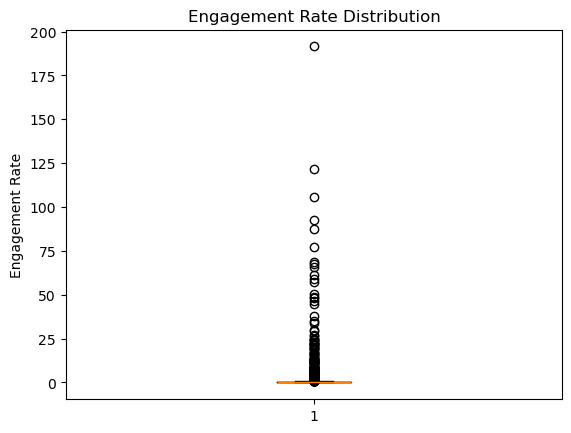

In [117]:
plt.boxplot(df['engagement_rate'])
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')
plt.show()

###### 📝Most engagement rate values are concentrated near the lower end, with several extreme high-value outliers reaching nearly 200, indicating strong right skewness.

***********************************************

#### 🔢 Count Plot

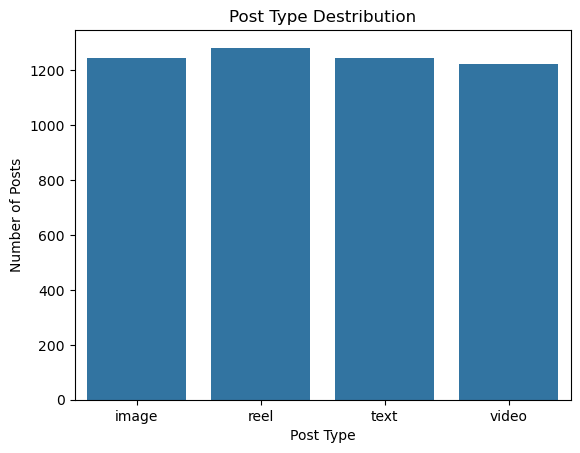

In [136]:
sns.countplot(x=df['post_type'])
plt.title('Post Type Destribution')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.show()

###### 📝Reels are the most common post type, while videos are the least common. Overall, the distribution of post types is fairly balanced.

*************************************************

#### 🎻 Violin Plot

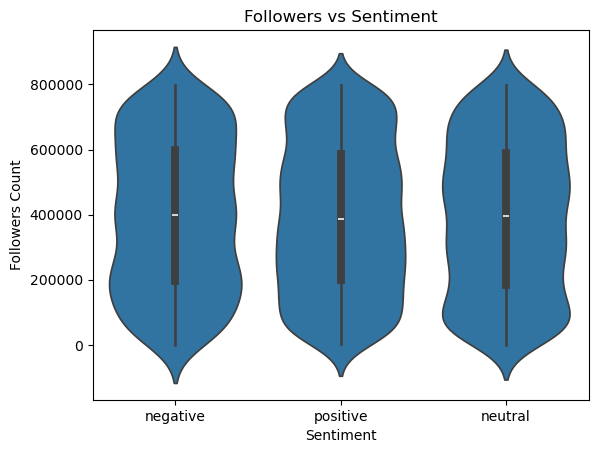

In [119]:
sns.violinplot(x='sentiment', y='follower_count', data=df)
plt.xlabel('Sentiment')
plt.ylabel('Followers Count')
plt.title('Followers vs Sentiment')
plt.show()

###### 📝Follower count distributions are broadly similar across positive, neutral, and negative sentiment, with comparable median values and overall ranges.

*****************************************

#### 🔥 Correlation Heatmap

In [120]:
num_columns = df[['age', 'likes', 'comments', 'shares',
       'watch_time_sec', 'impression_count', 'follower_count',
       'engagement_rate', 'hashtag_count']]
num_columns

,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
0,43,7011,354,1157,5726,44650,81734,0.190862,3
1,33,11750,2606,1807,5947,80216,5963,0.201493,1
2,32,4862,344,955,6946,44858,501783,0.137345,1
3,51,5350,1083,1049,229,70455,480212,0.106195,3
4,34,12682,2735,1300,4798,6019,383936,2.777372,1
...,...,...,...,...,...,...,...,...,...
4995,44,16210,2013,1837,6190,42977,646147,0.466761,2
4996,38,16924,2734,1583,7764,34196,584603,0.621155,2
4997,63,13487,1502,167,7466,23680,483550,0.679688,2
4998,13,16894,1289,1713,4991,89013,183295,0.223518,3


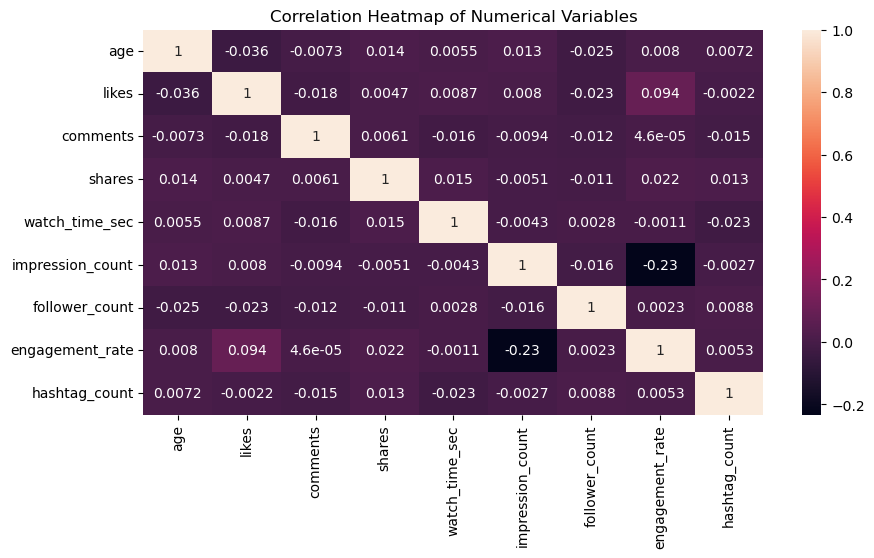

In [121]:
plt.figure(figsize=(10,5))
sns.heatmap(num_columns.corr(), annot=True)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

###### 📝Most numerical variables show very weak correlations. Impression count has the strongest relationship with engagement rate, showing a moderate negative correlation of -0.23, while the remaining relationships are close to zero.

************************************************************

#### 🖱️ Interactive Plotly Bar Plot

In [122]:
avg_engagement_by_type = df.groupby('post_type')['engagement_score'].mean()
avg_engagement_by_type

post_type
image    12649.321572
reel     12523.974279
text     12613.164659
video    12664.498776
Name: engagement_score, dtype: float64

In [123]:
avg_engagement_df = pd.DataFrame(avg_engagement_by_type).reset_index()

In [124]:
avg_engagement_df

,post_type,engagement_score
0,image,12649.321572
1,reel,12523.974279
2,text,12613.164659
3,video,12664.498776


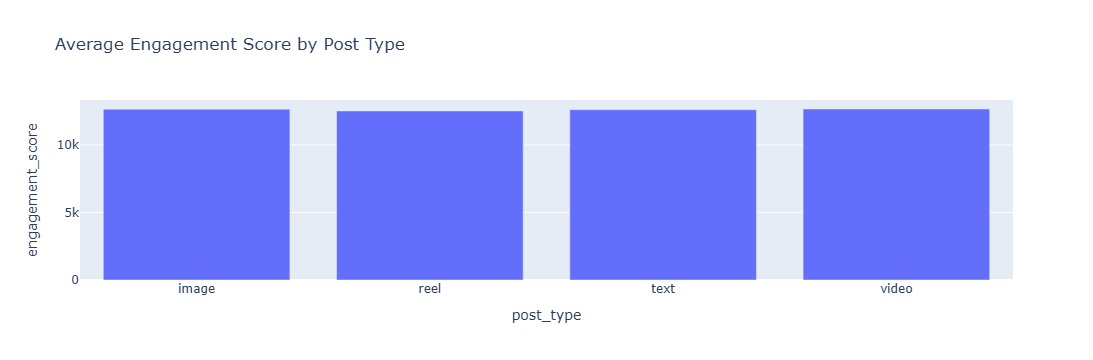

In [125]:
fig = px.bar(data_frame=avg_engagement_df, x='post_type', y='engagement_score', title='Average Engagement Score by Post Type')
fig.show()

###### 📝Video posts have the highest average engagement score, while reels have the lowest. However, the differences between post types are relatively small.

***************************************************

## Final Insights

#### 🏆 Best-performing content category → Music

In [126]:
df.groupby('post_category')['engagement_score'].mean()

post_category
education    12578.261490
fashion      12356.377104
fitness      12457.685926
food         12739.209106
lifestyle    12639.471170
music        12788.406299
tech         12686.407519
travel       12650.410000
Name: engagement_score, dtype: float64

###### 📝Music is the best-performing content category, with the highest average engagement score of 12,788.41, while fashion has the lowest at 12,356.38.

#### 👥 Age vs engagement → 26–40 has highest engagement

In [130]:
# Creating a new age group column
df['age_group'] = pd.cut(df['age'], bins = [10, 26, 41, 56, 66], labels = ['10-25', '26-40', '41-55', '56-65'])

In [133]:
df['age_group'].value_counts().sort_index()

age_group
10-25    1282
26-40    1620
41-55    1363
56-65     735
Name: count, dtype: int64

In [134]:
df.groupby('age_group')['engagement_score'].mean()

C:\Users\aamia\AppData\Local\Temp\ipykernel_27024\1150080888.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



age_group
10-25    12730.134945
26-40    12824.719136
41-55    12476.879677
56-65    12186.801361
Name: engagement_score, dtype: float64

###### 📝Users aged 26–40 have the highest average engagement score, while users aged 56–65 have the lowest. Overall, engagement tends to decrease among older age groups.

#### 🌍 Country vs engagement rate → Brazil

In [135]:
df.groupby('country')['engagement_rate'].mean()

country
Australia    1.324339
Brazil       1.540704
Canada       0.916659
France       1.146402
Germany      0.759000
India        0.655005
Japan        0.769623
UAE          1.112352
UK           0.850966
USA          0.576580
Name: engagement_rate, dtype: float64

###### 📝Brazil has the highest average engagement rate at 1.54, followed by Australia at 1.32. The USA has the lowest average engagement rate at 0.58, indicating considerable variation in engagement across countries.

#### ☑️ Verification vs engagement → Verified slightly higher

In [137]:
df.groupby('is_verified')['engagement_rate'].mean()

is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64

###### Verified users have a slightly higher average engagement rate (1.05) compared to non-verified users (0.95), suggesting that verification may be associated with higher engagement.

#### ⏰ Time of day → Cannot be analyzed, no time data

##### 📝The posted_at column contains date information but no time component. Therefore, time-of-day analysis cannot be performed using this dataset.

In [131]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count', 'engagement_score', 'log_engagement_rate',
       'posted_date', 'age_group'],
      dtype='object')

#### 📱 Device vs watch time → Mobile highest

In [148]:
df.groupby('device_type')['watch_time_sec'].mean()

device_type
desktop    3974.792521
mobile     4087.830760
tablet     3979.736429
Name: watch_time_sec, dtype: float64

###### 📝Mobile users have the highest average watch time at 4,087.83 seconds, while desktop users have the lowest at 3,974.79 seconds. This suggests that device type has a relatively small impact on watch time.

#### 💬 Sentiment vs engagement rate → Negative highest

In [150]:
df.groupby('sentiment')['engagement_rate'].mean()

sentiment
negative    1.038486
neutral     0.991170
positive    0.919744
Name: engagement_rate, dtype: float64

###### 📝Negative sentiment posts have the highest average engagement rate (1.04), while positive sentiment posts have the lowest (0.92). This suggests that negative-sentiment content tends to receive slightly higher engagement than positive content.

#### 💬 Sentiment vs engagement score → Negative highest

In [151]:
df.groupby('sentiment')['engagement_score'].mean()

sentiment
negative    12731.445833
neutral     12448.105435
positive    12665.705929
Name: engagement_score, dtype: float64

###### 📝Negative-sentiment posts have the highest average engagement score (12,731.45), while neutral-sentiment posts have the lowest (12,448.11). This indicates that negative content tends to receive slightly higher engagement than neutral and positive content.

***************************************************************

## 📋 Overall Summary

This project analyzed 5,000 social media records to understand user engagement patterns across different content types, categories, countries, age groups, devices, verification status, and sentiment. The dataset was first cleaned by handling missing values, checking for duplicates, validating categorical values, correcting data types, and checking for unrealistic engagement values. Missing numerical values were imputed using the mean, while missing categorical values were filled using the mode. No duplicate records or negative values were found in the likes, comments, or shares columns.

Several new fields were created to support the analysis, including hashtag count, engagement score, and log-transformed engagement rate. The engagement rate showed strong positive skewness and extreme values, so the log transformation was used to reduce the influence of these outliers.

Exploratory analysis showed that video posts had the highest average engagement score, although the differences between post types were relatively small. Among content categories, music achieved the highest average engagement score, while fashion had the lowest. Brazil recorded the highest average engagement rate among the countries analyzed, while the USA had the lowest. Users aged 26–40 showed the highest average engagement score, with engagement generally decreasing among the older age groups.

The analysis also found that verified users had a slightly higher average engagement rate than non-verified users. Among devices, mobile users had the highest average watch time, although the difference between devices was relatively small. Looking at sentiment, negative-sentiment posts recorded the highest average engagement rate and engagement score, while neutral posts had the lowest average engagement score.

The visualizations supported these findings and revealed that most numerical variables had weak correlations with one another. In particular, likes and impressions showed almost no linear relationship. The analysis of posting time could not be performed because the `posted_at` column contained date information without a time component.

Overall, the analysis suggests that content category, age group, country, sentiment, verification status, and device type are associated with differences in social media engagement, although many of these differences are relatively small. The findings provide a useful overview of engagement patterns and demonstrate how Python, Pandas, NumPy, Matplotlib, Seaborn, and Plotly can be used to clean, analyze, visualize, and derive insights from social media data.